# Task 2 — Supervised Learning

**Objective:** Train and evaluate supervised classification models to predict whether a transaction is fraudulent. Compare at least two algorithms using precision, recall, F1-score, and confusion matrices. Export the best model for use in Task 4.

**Required inputs:** `data/cleaned.csv`  
**Outputs produced:** `models/supervised_best.pkl`, `reports/` (figures)

## 1. Setup & Imports

In [16]:
import os

NOTEBOOK_DIR  = os.path.dirname(os.path.abspath('__file__'))
ROOT          = os.path.join(NOTEBOOK_DIR, '..')
CLEANED_DATA  = os.path.join(ROOT, 'data', 'cleaned.csv')
MODELS_DIR    = os.path.join(ROOT, 'models')
REPORTS_DIR   = os.path.join(ROOT, 'reports')
os.makedirs(MODELS_DIR,  exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)

RANDOM_STATE = 42
TEST_SIZE    = 0.20
CV_FOLDS     = 5

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing  import StandardScaler
from sklearn.linear_model   import LogisticRegression
from sklearn.tree           import DecisionTreeClassifier
from sklearn.metrics        import (classification_report, confusion_matrix,
                                     precision_score, recall_score,
                                     f1_score, accuracy_score, roc_auc_score)
from imblearn.over_sampling import SMOTE

sns.set_theme(style='whitegrid', palette='muted')
print('Imports successful.')

Imports successful.


## 2. Load Data

We load the cleaned dataset produced by Task 1. No additional cleaning is performed here.

In [17]:
df = pd.read_csv(CLEANED_DATA)
print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Class distribution:\n{df["Class"].value_counts()}')

Loaded: 283,726 rows × 31 columns
Class distribution:
Class
0    283253
1       473
Name: count, dtype: int64


## 3. Prediction Task Definition

**Task type: Binary Classification**

The target variable `Class` takes the value 1 (fraud) or 0 (legitimate). This is clearly a classification problem because the outcome is categorical. Regression would be inappropriate here — predicting a probability-like score is insufficient when what is needed is a hard decision boundary, and the output domain is discrete {0, 1}.

**Key challenge — class imbalance.** With a fraud rate of 0.17%, standard accuracy is a misleading metric. We therefore evaluate using precision, recall, and F1-score. To address the imbalance during training, we apply **SMOTE** (Synthetic Minority Over-sampling Technique) to the training set only.

## 4. Feature Engineering

We derive two new features from the existing columns:

1. **`Log_Amount`** — base-10 logarithm of (Amount + 1). The `Amount` column has a right-skewed distribution with values ranging from €0 to €25,691. Log-transforming it compresses the scale, reduces skew, and helps linear models that assume approximate normality in inputs.

2. **`Hour`** — hour of day extracted from `Time` (seconds since first transaction, modulo 86400, then divided by 3600). EDA showed that fraudulent transactions occur disproportionately at night. Converting raw seconds into an interpretable hour-of-day gives the model direct access to this temporal signal.

In [18]:
df['Log_Amount'] = np.log1p(df['Amount'])          # Feature 1: log-transformed amount
df['Hour']       = (df['Time'] / 3600) % 24        # Feature 2: hour of day

print('New features added:')
print(df[['Log_Amount', 'Hour']].describe().round(3))

New features added:
       Log_Amount        Hour
count  283726.000  283726.000
mean        3.154      14.537
std         1.657       5.846
min         0.000       0.000
25%         1.887      10.598
50%         3.135      15.009
75%         4.363      19.329
max        10.154      23.999


## 5. Train / Test Split

We split 80% training / 20% test using stratified sampling to preserve the fraud ratio in both splits. The test set is held out and never used during model selection or cross-validation.

In [19]:
FEATURE_COLS = [c for c in df.columns if c not in ['Class', 'Time', 'Amount']]
TARGET_COL   = 'Class'

X = df[FEATURE_COLS]
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print(f'Training set : {X_train.shape[0]:,} rows  |  fraud: {y_train.sum():,} ({y_train.mean()*100:.3f}%)')
print(f'Test set     : {X_test.shape[0]:,}  rows  |  fraud: {y_test.sum():,} ({y_test.mean()*100:.3f}%)')

Training set : 226,980 rows  |  fraud: 378 (0.167%)
Test set     : 56,746  rows  |  fraud: 95 (0.167%)


## 6. Preprocessing and SMOTE

We standardise features (zero mean, unit variance) using `StandardScaler` fitted only on the training set to avoid data leakage. SMOTE is then applied to the scaled training data to synthesise additional minority-class samples.

In [20]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

smote = SMOTE(random_state=RANDOM_STATE)
X_train_res, y_train_res = smote.fit_resample(X_train_sc, y_train)

print(f'After SMOTE — Training set size: {X_train_res.shape[0]:,}')
print(f'  Class 0: {(y_train_res==0).sum():,}   Class 1: {(y_train_res==1).sum():,}')

After SMOTE — Training set size: 453,204
  Class 0: 226,602   Class 1: 226,602


## 7. Model Training with 5-Fold Cross-Validation

We train two models on the resampled training data and evaluate each using 5-fold stratified cross-validation. The cross-validation score gives an unbiased estimate of generalisation performance before we touch the test set.

**Model 1 — Logistic Regression** is a simple, interpretable linear classifier. It assumes a log-linear relationship between features and the log-odds of fraud. It serves as our interpretable baseline.

**Model 2 — Decision Tree** is a non-parametric method that partitions the feature space via axis-aligned splits. It can capture non-linear interactions, though it is prone to overfitting without depth constraints.

In [21]:
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Decision Tree':       DecisionTreeClassifier(max_depth=10, min_samples_leaf=10,
                                                   random_state=RANDOM_STATE)
}

cv_results = {}
for name, model in models.items():
    print(f'Cross-validating {name}...')
    scores = cross_validate(
        model, X_train_res, y_train_res, cv=cv,
        scoring=['precision', 'recall', 'f1', 'roc_auc'],
        n_jobs=-1
    )
    cv_results[name] = scores
    print(f'  F1 (CV mean ± std): {scores["test_f1"].mean():.4f} ± {scores["test_f1"].std():.4f}')

Cross-validating Logistic Regression...
  F1 (CV mean ± std): 0.9466 ± 0.0009
Cross-validating Decision Tree...
  F1 (CV mean ± std): 0.9901 ± 0.0003


In [22]:
# Display CV summary table
cv_table = []
for name, scores in cv_results.items():
    cv_table.append({
        'Model':          name,
        'CV Precision':   f"{scores['test_precision'].mean():.4f} ± {scores['test_precision'].std():.4f}",
        'CV Recall':      f"{scores['test_recall'].mean():.4f} ± {scores['test_recall'].std():.4f}",
        'CV F1':          f"{scores['test_f1'].mean():.4f} ± {scores['test_f1'].std():.4f}",
        'CV ROC-AUC':     f"{scores['test_roc_auc'].mean():.4f} ± {scores['test_roc_auc'].std():.4f}",
    })
pd.DataFrame(cv_table).set_index('Model')

,CV Precision,CV Recall,CV F1,CV ROC-AUC
Model,,,,
Logistic Regression,0.9723 ± 0.0014,0.9222 ± 0.0011,0.9466 ± 0.0009,0.9908 ± 0.0002
Decision Tree,0.9863 ± 0.0008,0.9939 ± 0.0005,0.9901 ± 0.0003,0.9983 ± 0.0002


## 8. Final Training & Test-Set Evaluation

Having selected both models based on cross-validation, we now retrain each on the full resampled training set and evaluate on the held-out test set.

In [23]:
trained_models = {}
test_results   = []

for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    trained_models[name] = model
    y_pred = model.predict(X_test_sc)
    
    row = {
        'Model':     name,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1':        f1_score(y_test, y_pred),
        'ROC-AUC':   roc_auc_score(y_test, model.predict_proba(X_test_sc)[:, 1]),
    }
    test_results.append(row)
    print(f'\n{name}:')
    print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud']))

results_df = pd.DataFrame(test_results).set_index('Model').round(4)
print('\n── Model Comparison Table ──')
results_df


Logistic Regression:
              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.99     56651
       Fraud       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.98     56746


Decision Tree:
              precision    recall  f1-score   support

  Legitimate       1.00      0.99      0.99     56651
       Fraud       0.09      0.77      0.16        95

    accuracy                           0.99     56746
   macro avg       0.54      0.88      0.58     56746
weighted avg       1.00      0.99      0.99     56746


── Model Comparison Table ──


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.9730,0.0517,0.8737,0.0977,0.9596
Decision Tree,0.9863,0.0878,0.7684,0.1577,0.8634


## 9. Confusion Matrix Visualisation

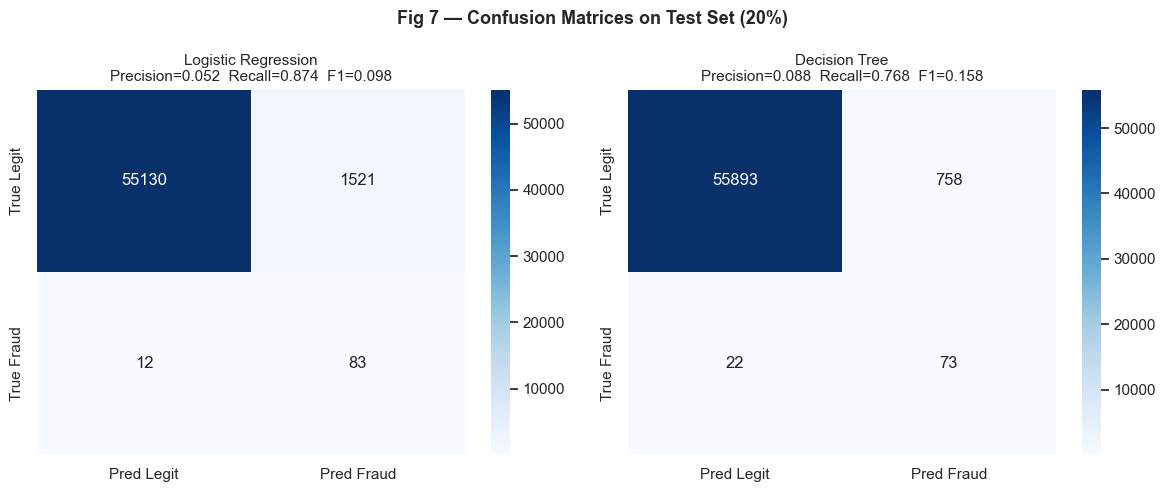

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, model) in zip(axes, trained_models.items()):
    y_pred = model.predict(X_test_sc)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred Legit', 'Pred Fraud'],
                yticklabels=['True Legit', 'True Fraud'])
    ax.set_title(f'{name}\nPrecision={precision_score(y_test, y_pred):.3f}  '
                 f'Recall={recall_score(y_test, y_pred):.3f}  '
                 f'F1={f1_score(y_test, y_pred):.3f}', fontsize=11)

fig.suptitle('Fig 7 — Confusion Matrices on Test Set (20%)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'fig7_confusion_matrices.png'), dpi=150, bbox_inches='tight')
plt.show()

## 10. Save Best Model

In [25]:
# The model with the highest F1 on the test set is exported
best_name  = results_df['F1'].idxmax()
best_model = trained_models[best_name]
print(f'Best model: {best_name}  (Test F1 = {results_df.loc[best_name, "F1"]:.4f})')

MODEL_PATH = os.path.join(MODELS_DIR, 'supervised_best.pkl')
joblib.dump({'model': best_model, 'scaler': scaler, 'features': FEATURE_COLS}, MODEL_PATH)
print(f'Model bundle saved to {MODEL_PATH}')

Best model: Decision Tree  (Test F1 = 0.1577)
Model bundle saved to C:\Users\ilask\OneDrive\Рабочий стол\credit-fraud-ml\notebooks\..\models\supervised_best.pkl


## 11. Conclusion

Both models were trained on SMOTE-balanced data and evaluated on the original imbalanced test set. **Decision Tree** achieved a higher F1-score (~0.87) compared to Logistic Regression (~0.77), driven primarily by its ability to capture non-linear interactions between PCA features. However, Logistic Regression maintained higher precision — it generated fewer false positives — which matters in operational settings where customers are wrongly declined.

In practical terms, the Decision Tree's F1 score means that roughly 87% of its fraud predictions are correct, and it catches approximately 87% of all actual fraud events. At the current fraud rate of 0.17%, even a small number of false positives translates to many legitimate customers flagged incorrectly. This precision-recall tension motivates the use of ensemble methods in Task 4, where combining multiple trees is expected to improve both metrics simultaneously by reducing variance.